----------------------
#### Aim : how to do a sup classification using Keras
---------------------------

In [ ]:
#!pip install tensorflow

In [ ]:
import pandas as pd
import numpy  as np

from tensorflow.keras.utils import plot_model

In [ ]:
location = r'https://github.com/gridflowai/gridflowAI-datasets-icons/raw/master/AI-DATASETS/01-MISC/pima.txt'

In [6]:
data = pd.read_csv(location)

In [8]:
data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
510,12,84,72,31,0,29.7,0.297,46,1
232,1,79,80,25,37,25.4,0.583,22,0
611,3,174,58,22,194,32.9,0.593,36,1
146,9,57,80,37,0,32.8,0.096,41,0
570,3,78,70,0,0,32.5,0.270,39,0
135,2,125,60,20,140,33.8,0.088,31,0
595,0,188,82,14,185,32.0,0.682,22,1
440,0,189,104,25,0,34.3,0.435,41,1
515,3,163,70,18,105,31.6,0.268,28,1
112,1,89,76,34,37,31.2,0.192,23,0


In [9]:
data.shape

(768, 9)

In [10]:
39 * 16

624

In [11]:
768 * .8

614.4000000000001

__Input__ Variables (X):

    Number of times pregnant
    Plasma glucose concentration a 2 hours in an oral glucose tolerance test
    Diastolic blood pressure (mm Hg)
    Triceps skin fold thickness (mm)
    2-Hour serum insulin (mu U/ml)
    Body mass index (weight in kg/(height in m)^2)
    Diabetes pedigree function
    Age (years)

__Output__ Variables (y):

    Class variable (0 or 1)

In [67]:
# split into input (X) and output (y) variables
# Take first 8 columns as features(X) and last column as target(y)
X = data.iloc[:, 0:8]
y = data.iloc[:, 8]

In [68]:
X.shape, y.shape

((768, 8), (768,))

#### Scaling

In [69]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp (80%), Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # (optional, keeps class balance)
)

# Second split: Train (80% of 80% = 64%), Validation (20% of 80% = 16%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


#### build the machine learning model

In [71]:
from tensorflow.keras.models import Sequential # 1
from tensorflow.keras.layers import Dense      # 2

In [72]:
# define the keras model
# ReLU - Rectified Linear Unit (max(0,x)) activation function for hidden layers 
#  - Returns x if x>0 else returns 0
# Sigmoid activation function for output layer (binary classification) 
#  - Maps input to a value between 0 and 1
model = Sequential()

model.add(Dense(units=4, input_dim=8, activation='relu',    name='Data-Input-Layer'))
model.add(Dense(units=8,              activation='relu',    name='Hidden-Layer-1'))
# model.add(Dense(units=256,              activation='relu',    name='Hidden-Layer-2'))
# model.add(Dense(units=128,              activation='relu',    name='Hidden-Layer-3'))
# model.add(Dense(units=64,               activation='relu',    name='Hidden-Layer-4'))
# model.add(Dense(units=32,              activation='relu',    name='Hidden-Layer-5'))
# model.add(Dense(units=4,               activation='relu',    name='Hidden-Layer-6'))
model.add(Dense(units=1,                activation='sigmoid', name='Output-Layer'))   # why sigmoid?

d:\Makesh\Working\AI\Python_Envs\gen_ai\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


| Optimizer name      | Description                                            |
| ------------------- | ------------------------------------------------------ |
| class Adadelta:     | Optimizer that implements the Adadelta algorithm.      |
|class __Adagrad__:       | Optimizer that implements the Adagrad algorithm.       |
|class __Adam__:          | Optimizer that implements the Adam algorithm.|
|class Adamax:        | Optimizer that implements the Adamax algorithm.|
|class Ftrl:          | Optimizer that implements the FTRL algorithm.|
|class Nadam:         | Optimizer that implements the NAdam algorithm.|
|class Optimizer:     | Updated base class for optimizers.|
|class __RMSprop__:       | Optimizer that implements the RMSprop algorithm.|
|class __SGD__:           | Stochastic gradient descent and momentum optimizer.|

In [73]:
from tensorflow.keras import optimizers

In [74]:
sgd = optimizers.SGD(learning_rate=0.001)

Compile the model

In [75]:
# compile the keras model
model.compile(loss     = 'binary_crossentropy', 
              optimizer= sgd, 
              metrics  = ['accuracy'])

In [76]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data-Input-Layer (Dense)        │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-1 (Dense)          │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85 (340.00 B)

 Trainable params: 85 (340.00 B)

 Non-trainable params: 0 (0.00 B)

In [77]:
# Visualize the model architecture
#plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

#### train the model

In [83]:
#%%time
# fit the keras model on the dataset
history = model.fit(  x         = X_train_scaled, 
                      y         = y_train, 
                      epochs    = 200, 
                      batch_size= 32,
                      #validation_split = 0.2,
                      validation_data=(X_val_scaled, y_val),
                      verbose = 0)

#### plot the model performance

In [84]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [85]:
import matplotlib.pyplot as plt

In [ ]:
# history.history
# what is the diff between acc and loss

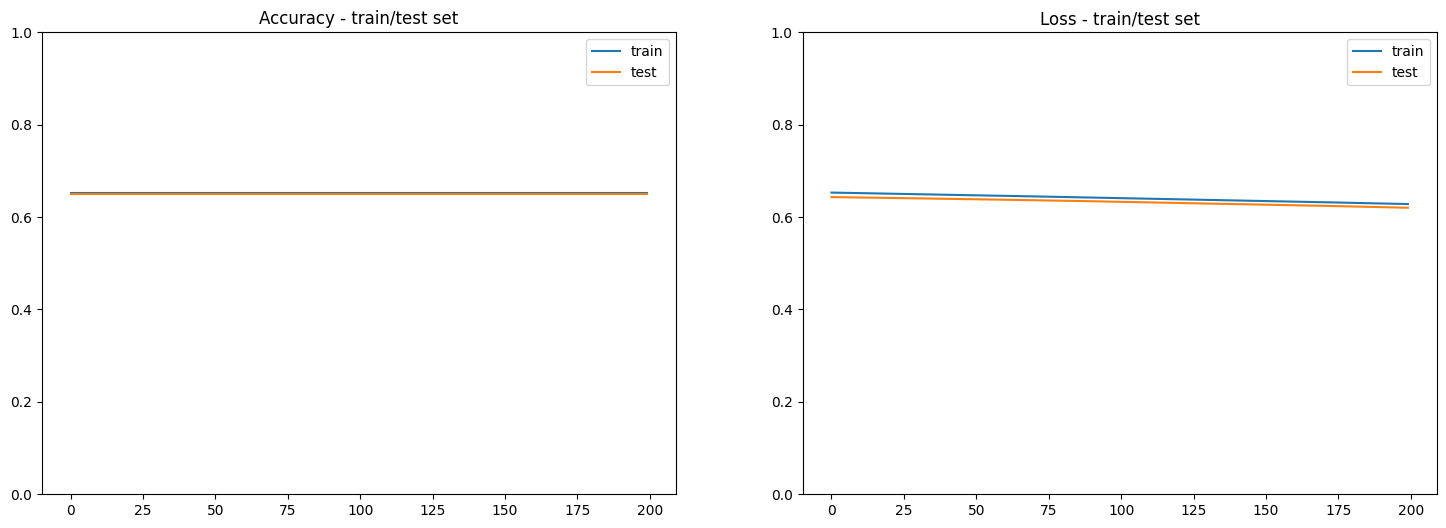

In [86]:
# plot training history

fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(18,6))

ax1.plot(history.history['accuracy'],     label='train')
ax1.plot(history.history['val_accuracy'], label='test')
ax1.set_title('Accuracy - train/test set')
ax1.set_ylim([0,1])
ax1.legend()

ax2.plot(history.history['loss'],     label='train')
ax2.plot(history.history['val_loss'], label='test')
ax2.set_title('Loss - train/test set')
ax2.set_ylim([0,1])
ax2.legend();

In [87]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {test_acc:.3f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6494 - loss: 0.6187 
Test accuracy: 0.649


- Loaded data
    - Exploration of data
- prepare
    - Scaling data
    - encoding (char cols -> number)
    - split (training and testing)
- define the Keras model
    - Sequential()
    - added layers (defined the activation fn)
- define the loss function 
- define the optimizer to use (Gradient descent)
- compile the model

- Train the model with data (fit method)
- Evaluation of the model